## Import libraries

In [2]:
!pip install optuna mlflow importnb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 122.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 129.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import RobustScaler, MinMaxScaler
import time
import mlflow
import mlflow.pytorch
import scipy.signal
import torch.nn.functional as F
from google.colab import drive
import sys
import cv2
from importnb import Notebook

In [4]:
file_path = ('/content/drive/MyDrive/2025_PPG_GLUC/Code/Model/Plots')

if file_path not in sys.path:
  sys.path.append(file_path)

# with Notebook():
with Notebook():
  import Eval_Metrics
  import Parkes_Error_Grid
from Eval_Metrics import plot_performance
from Parkes_Error_Grid import parkes_error_grid

In [146]:
DATA_DIR = '/content/drive/MyDrive/2025_PPG_GLUC/Data/Processed Data/Full Pipeline VitalDB/both_h1_h2_notch_filters_length/Model Data Normalized/'

# Output Directory
MODEL_SAVE_PATH = '/content/drive/MyDrive/2025_PPG_GLUC/Models/ResNet16_15bin_with_demographics/test_no_norm/'
if not os.path.exists(MODEL_SAVE_PATH):
    os.makedirs(MODEL_SAVE_PATH)

# MLflow
mlflow.set_tracking_uri("file:/content/drive/MyDrive/2025_PPG_GLUC/mlruns")

# Hyperparameters
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-3
SEED = 42
INPUT_LENGTH = 1500

# Device
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Loading dataset

In [18]:
class PPGDataset(Dataset):
    def __init__(self, X, y, M, d, augment=False):
        self.X = X
        self.y = y
        self.m = M
        self.d = d
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]
        m = self.m[idx].astype(np.float32)
        d = self.d[idx]

        # Augmentation
        if self.augment and np.random.rand() > 0.5:
            scale = np.random.uniform(0.9, 1.1)
            x = x.copy()
            x[m>0] *= scale
        x_t = torch.from_numpy(x).unsqueeze(0)
        m_t = torch.from_numpy(m).unsqueeze(0)
        y_t = torch.tensor(y, dtype=torch.float32)
        d_t = torch.from_numpy(d).float()

        return x_t, y_t, m_t, d_t

In [19]:
def load_data():
    print("Loading data")
    X_train = np.load(os.path.join(DATA_DIR, 'X_train_pad_before_concat.npy'))
    y_train = np.load(os.path.join(DATA_DIR, 'y_train_pad_before_concat.npy'))
    m_train = np.load(os.path.join(DATA_DIR, 'mask_train_pad_before_concat.npy'))
    d_train = np.load(os.path.join(DATA_DIR, 'demo_train_pad_before_concat.npy'))
    X_val = np.load(os.path.join(DATA_DIR, 'X_val_pad_before_concat.npy'))
    y_val = np.load(os.path.join(DATA_DIR, 'y_val_pad_before_concat.npy'))
    m_val = np.load(os.path.join(DATA_DIR, 'mask_val_pad_before_concat.npy'))
    d_val = np.load(os.path.join(DATA_DIR, 'demo_val_pad_before_concat.npy'))


    if os.path.exists(os.path.join(DATA_DIR, 'X_test_pad_before_concat.npy')):
        X_test = np.load(os.path.join(DATA_DIR, 'X_test_pad_before_concat.npy'))
        y_test = np.load(os.path.join(DATA_DIR, 'y_test_pad_before_concat.npy'))
        m_test = np.load(os.path.join(DATA_DIR, 'mask_test_pad_before_concat.npy'))
        d_test = np.load(os.path.join(DATA_DIR, 'demo_test_pad_before_concat.npy'))
    else:
        X_test, y_test = X_val, y_val
    print("Train sizes:", X_train.shape, y_train.shape, m_train.shape, d_train.shape)
    print("Val sizes:", X_val.shape, y_val.shape, m_val.shape, d_val.shape)
    print("Test sizes:", X_test.shape, y_test.shape, m_test.shape, d_test.shape)
    # Note: No manual scaling here because Dataset handles Z-score internally
    loaders = {
        'train': DataLoader(PPGDataset(X_train, y_train, m_train, d_train, augment=False), batch_size=BATCH_SIZE, shuffle=True),
        'val': DataLoader(PPGDataset(X_val, y_val, m_val, d_val, augment=False), batch_size=BATCH_SIZE, shuffle=False),
        'test': DataLoader(PPGDataset(X_test, y_test, m_test, d_test, augment=False), batch_size=BATCH_SIZE, shuffle=False)
    }
    return loaders

## Model Architecture

## DONT TOUCH

In [42]:
class CNNBackbone(nn.Module):
  def __init__(self, in_channels=1, out_channels=1):
    super().__init__()
    self.conv1 = nn.Conv1d(in_channels, 64, kernel_size=7, stride=2, padding=3)
    self.bn1 = nn.BatchNorm1d(64)

    self.conv2 = nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2)
    self.bn2 = nn.BatchNorm1d(128)

    self.conv3 = nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1)
    self.bn3 = nn.BatchNorm1d(256)

    # self.conv4 = nn.Conv1d(256, 128, kernel_size=3, stride=1, padding=2, dilation=2, bias=False)
    # self.bn4 = nn.BatchNorm1d(128)

    self.emb_dim = 256

  def forward(self, x):
    x = F.relu(self.bn1(self.conv1(x)))
    x = F.relu(self.bn2(self.conv2(x)))
    x = F.relu(self.bn3(self.conv3(x)))
    # x = F.relu(self.bn4(self.conv4(x)))
    return x

In [43]:
def masked_gap_from_zero_padding(features, mask, eps=1e-6):
  """
  features: [B, C, T_feat]
  returns:  [B, C]
  """
  if mask.dim() == 2:
        mask = mask.unsqueeze(1)
  B, C, T_feat = features.shape
  mask_feat = F.interpolate(mask.float(), size=T_feat, mode="area")  # [B,1,T_feat]
  masked = features * mask_feat
  denom = mask_feat.sum(dim=-1).clamp(min=eps)  # [B,1]
  return masked.sum(dim=-1) / denom             # [B,C]

In [44]:
class DemoMLP(nn.Module):
  def __init__(self, in_dim, emb_dim=64, dropout=0.2):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(in_dim, 64),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(64, emb_dim),
        nn.ReLU(),
    )
    self.emb_dim = emb_dim

  def forward(self, d):
    if d.dim() == 3:
      d = d.squeeze(1)
    return self.net(d)

In [45]:
class MultiModalModel(nn.Module):
  def __init__(self, demo_dim=8, dropout=0.3):
    super().__init__()
    self.cnn = CNNBackbone()
    self.mlp = DemoMLP(demo_dim, emb_dim=256, dropout=dropout)
    fused_dim = self.cnn.emb_dim + self.mlp.emb_dim

    self.head = nn.Sequential(
        nn.Linear(fused_dim, 512),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(256, 64),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(64,1)
    )

  def forward(self, x, m=None, d=None):
    feats = self.cnn(x)
    sig_emb = masked_gap_from_zero_padding(feats, m)
    if d is None:
      fused = sig_emb
    else:
      demo_emb = self.mlp(d)
      # print(sig_emb.shape)
      # print(demo_emb.shape)
      fused = torch.cat([sig_emb, demo_emb], dim=1)

    out = self.head(fused).squeeze(-1)
    return out

## Training

In [46]:
def plot_performance(model, loaders, history, best_val_mae, MODEL_SAVE_PATH, device):
    # Now the function 'knows' what model, loaders, and device are
    model.eval()
    preds, trues = [], []

    with torch.no_grad():
        for x, y, lens, demos in loaders['test']:
            x, lens, demos = x.to(device), lens.to(device), demos.to(device)
            out = model(x, lens, demos)
            preds.extend(out.cpu().numpy())
            trues.extend(y.numpy())

    preds = np.array(preds).flatten()
    trues = np.array(trues).flatten()

    preds = np.array(preds); trues = np.array(trues)
    # 1. METRICS
    mae = mean_absolute_error(trues, preds)
    rmse = np.sqrt(mean_squared_error(trues, preds))
    mard = np.mean(np.abs((trues - preds) / trues)) * 100
    r2 = r2_score(trues, preds)

    print(f"\n📊 TEST RESULTS:")
    print(f"   RMSE: {rmse:.2f} mg/dL")
    print(f"   MAE:  {mae:.2f} mg/dL")
    print(f"   MARD: {mard:.2f} %")
    print(f"   R^2:  {r2:.4f}")

    # 2. Plotting
    plt.figure(figsize=(14, 6))

    # MAE Subplot
    plt.subplot(1, 2, 1)
    plt.plot(history['t_mae'], label='Train MAE', linewidth=2)
    plt.plot(history['v_mae'], label='Val MAE', linewidth=2)
    plt.plot(history['test_mae'], label='Test MAE', linestyle='--', alpha=0.7)
    plt.ylim(15,35)
    plt.title(f'MAE Learning Curve\n(Best Val MAE: {best_val_mae:.2f})')
    plt.xlabel('Epoch'); plt.ylabel('MAE (mg/dL)')
    plt.legend(); plt.grid(True, alpha=0.3)

    # Loss Subplot
    plt.subplot(1, 2, 2)
    plt.plot(history['t_loss'], label='Train Loss')
    plt.plot(history['v_loss'], label='Val Loss')
    plt.plot(history['test_loss'], label='Test Loss', linestyle='--')
    plt.ylim(15, 40)
    plt.title('Loss (MSE) Learning Curve')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.legend(); plt.grid(True, alpha=0.3)

    plt.tight_layout()
    os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
    plt.savefig(os.path.join(MODEL_SAVE_PATH, 'learning_curves.png'))
    plt.show()
    return trues, preds

In [47]:
def train_step(model, loader, crit, opt):
    model.train()
    loss_sum, mae_sum, count = 0, 0, 0
    for x, y, lens, demo in loader:
        x, y, lens, demo = x.to(device), y.to(device), lens.to(device), demo.to(device)
        opt.zero_grad()
        pred = model(x, lens, demo)
        loss = crit(pred, y)
        loss.backward()
        opt.step()
        loss_sum += loss.item()*x.size(0); mae_sum += (pred-y).abs().sum().item(); count += x.size(0)
    return loss_sum/count, mae_sum/count

def val_step(model, loader, crit):
    model.eval()
    loss_sum, mae_sum, count = 0, 0, 0
    with torch.no_grad():
        for x, y, lens, demo in loader:
            x, y, lens, demo = x.to(device), y.to(device), lens.to(device), demo.to(device)
            pred = model(x, lens, demo)
            loss_sum += crit(pred, y).item()*x.size(0); mae_sum += (pred-y).abs().sum().item(); count += x.size(0)
    return loss_sum/count, mae_sum/count

In [48]:
def main():
    loaders = load_data()
    model = MultiModalModel().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.SmoothL1Loss(beta=10.0)

    best_path = os.path.join(MODEL_SAVE_PATH, 'best_model.pt')
    best_val_mae = float('inf')
    history = {'t_loss': [], 'v_loss': [], 'test_loss': [],
               't_mae': [], 'v_mae': [], 'test_mae': []}


    print("--- Starting Training ---")
    for epoch in range(EPOCHS):
        start = time.time()
        t_loss, t_mae = train_step(model, loaders['train'], criterion, optimizer)
        v_loss, v_mae = val_step(model, loaders['val'], criterion)
        test_loss, test_mae = val_step(model, loaders['test'], criterion)

        history['t_loss'].append(t_loss); history['t_mae'].append(t_mae)
        history['v_loss'].append(v_loss); history['v_mae'].append(v_mae)
        history['test_loss'].append(test_loss); history['test_mae'].append(test_mae)

        print(f"Ep {epoch+1}/{EPOCHS} | {time.time()-start:.0f}s | "
              f"T_MAE: {t_mae:.2f} | V_MAE: {v_mae:.2f} | Test_MAE: {test_mae:.2f}")


        if v_mae < best_val_mae:
            best_val_mae = v_mae
            torch.save(model.state_dict(), best_path)

    # --- EVALUATION ---
    print("\n--- Final Eval")

    model.load_state_dict(torch.load(best_path, map_location=device))

    trues, preds = plot_performance(
            model=model,
            loaders=loaders,
            history=history,
            best_val_mae=best_val_mae,
            MODEL_SAVE_PATH=MODEL_SAVE_PATH,
            device=device
        )

    mard = np.mean(np.abs((trues - preds) / trues)) * 100

    fig = parkes_error_grid(trues, preds, f"Parkes Grid (MARD: {mard:.1f}%)")
    fig.savefig(os.path.join(MODEL_SAVE_PATH, 'parkes_grid.png'))
    plt.show()


Loading data
Train sizes: (11634, 1500) (11634,) (11634, 1500) (11634, 8)
Val sizes: (2468, 1500) (2468,) (2468, 1500) (2468, 8)
Test sizes: (2409, 1500) (2409,) (2409, 1500) (2409, 8)
--- Starting Training ---
Ep 1/30 | 4s | T_MAE: 65.20 | V_MAE: 27.67 | Test_MAE: 26.15
Ep 2/30 | 4s | T_MAE: 27.20 | V_MAE: 27.32 | Test_MAE: 25.22
Ep 3/30 | 4s | T_MAE: 26.60 | V_MAE: 27.20 | Test_MAE: 24.96
Ep 4/30 | 4s | T_MAE: 26.27 | V_MAE: 26.90 | Test_MAE: 24.42
Ep 5/30 | 4s | T_MAE: 26.18 | V_MAE: 27.04 | Test_MAE: 24.10
Ep 6/30 | 4s | T_MAE: 25.80 | V_MAE: 27.26 | Test_MAE: 23.66
Ep 7/30 | 4s | T_MAE: 25.68 | V_MAE: 27.12 | Test_MAE: 23.43
Ep 8/30 | 4s | T_MAE: 25.66 | V_MAE: 27.22 | Test_MAE: 23.41
Ep 9/30 | 4s | T_MAE: 25.62 | V_MAE: 26.77 | Test_MAE: 23.23
Ep 10/30 | 4s | T_MAE: 25.44 | V_MAE: 27.33 | Test_MAE: 23.21
Ep 11/30 | 4s | T_MAE: 25.22 | V_MAE: 27.11 | Test_MAE: 22.96
Ep 12/30 | 4s | T_MAE: 25.16 | V_MAE: 27.10 | Test_MAE: 23.67
Ep 13/30 | 4s | T_MAE: 24.97 | V_MAE: 27.12 | Test_MAE

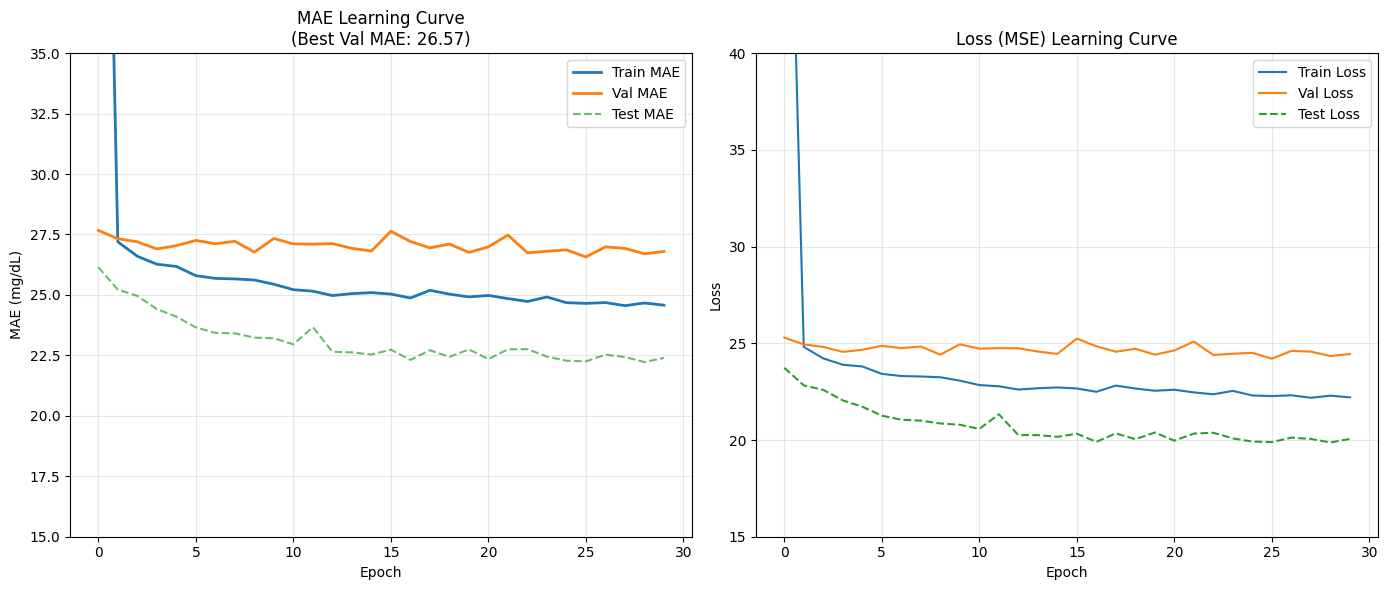

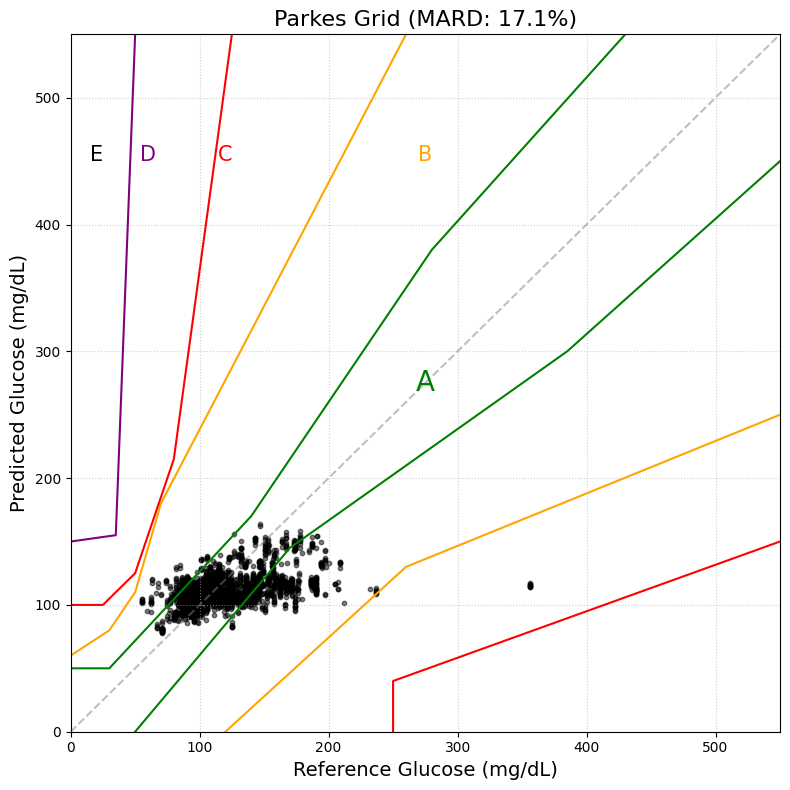

In [164]:
if __name__ == "__main__":
  main()

In [ ]:
y_train = np.load('/content/drive/MyDrive/2025_PPG_GLUC/Data/Model Data/100Hz_15pulses/bin_concat/with_demographics/y_train_pad_before_concat.npy')
y_val = np.load('/content/drive/MyDrive/2025_PPG_GLUC/Data/Model Data/100Hz_15pulses/bin_concat/with_demographics/y_val_pad_before_concat.npy')
y_test = np.load('/content/drive/MyDrive/2025_PPG_GLUC/Data/Model Data/100Hz_15pulses/bin_concat/with_demographics/y_test_pad_before_concat.npy')
y_train.shape

(11858,)

In [ ]:
y_mean = y_train.mean()
y_std = y_train.std()
print(f"Y train mean: {y_mean}, Y train std: {y_std}")

Y train mean: 121.29507446289062, Y train std: 36.34437561035156


In [ ]:
y_train_normalized = (y_train - y_mean) / y_std
y_val_n = (y_val - y_mean) / y_std
y_test_n = (y_test - y_mean)/ y_std

y_train_normalized.shape, y_val_n.shape, y_test_n.shape

((11858,), (2326,), (2424,))

In [ ]:
np.save('/content/drive/MyDrive/2025_PPG_GLUC/Data/Model Data/100Hz_15pulses/bin_concat/with_demographics/y_train_pad_before_concat_normalized.npy', y_train_normalized)

np.save('/content/drive/MyDrive/2025_PPG_GLUC/Data/Model Data/100Hz_15pulses/bin_concat/with_demographics/y_val_pad_before_concat_normalized.npy', y_val_n)

np.save('/content/drive/MyDrive/2025_PPG_GLUC/Data/Model Data/100Hz_15pulses/bin_concat/with_demographics/y_test_pad_before_concat_normalized.npy', y_test_n)

## DONT CHANGE

In [49]:
DATA_DIR = '/content/drive/MyDrive/2025_PPG_GLUC/Data/Model Data/100Hz_15pulses/bin_concat/test_min_max_norm/'

# Output Directory
MODEL_SAVE_PATH = '/content/drive/MyDrive/2025_PPG_GLUC/Models/ResNet16_15bin_with_demographics/ACTUAL BEST/'
if not os.path.exists(MODEL_SAVE_PATH):
    os.makedirs(MODEL_SAVE_PATH)

# MLflow
mlflow.set_tracking_uri("file:/content/drive/MyDrive/2025_PPG_GLUC/mlruns")

# Hyperparameters
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-3
SEED = 42
INPUT_LENGTH = 1500

# Device
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


Loading data
Train sizes: (11858, 1500) (11858,) (11858, 1500) (11858, 8)
Val sizes: (2326, 1500) (2326,) (2326, 1500) (2326, 8)
Test sizes: (2424, 1500) (2424,) (2424, 1500) (2424, 8)
--- Starting Training ---
Ep 1/30 | 3s | T_MAE: 48.76 | V_MAE: 27.13 | Test_MAE: 23.63
Ep 2/30 | 3s | T_MAE: 26.91 | V_MAE: 26.57 | Test_MAE: 22.84
Ep 3/30 | 3s | T_MAE: 26.69 | V_MAE: 26.34 | Test_MAE: 22.30
Ep 4/30 | 3s | T_MAE: 26.22 | V_MAE: 26.19 | Test_MAE: 22.08
Ep 5/30 | 3s | T_MAE: 25.83 | V_MAE: 27.10 | Test_MAE: 22.68
Ep 6/30 | 3s | T_MAE: 25.80 | V_MAE: 26.04 | Test_MAE: 21.89
Ep 7/30 | 3s | T_MAE: 25.74 | V_MAE: 27.12 | Test_MAE: 23.03
Ep 8/30 | 3s | T_MAE: 25.60 | V_MAE: 26.45 | Test_MAE: 22.16
Ep 9/30 | 3s | T_MAE: 25.63 | V_MAE: 26.02 | Test_MAE: 21.62
Ep 10/30 | 3s | T_MAE: 25.83 | V_MAE: 26.21 | Test_MAE: 21.95
Ep 11/30 | 3s | T_MAE: 25.33 | V_MAE: 26.21 | Test_MAE: 21.86
Ep 12/30 | 3s | T_MAE: 25.31 | V_MAE: 25.96 | Test_MAE: 21.60
Ep 13/30 | 3s | T_MAE: 25.18 | V_MAE: 26.31 | Test_MAE

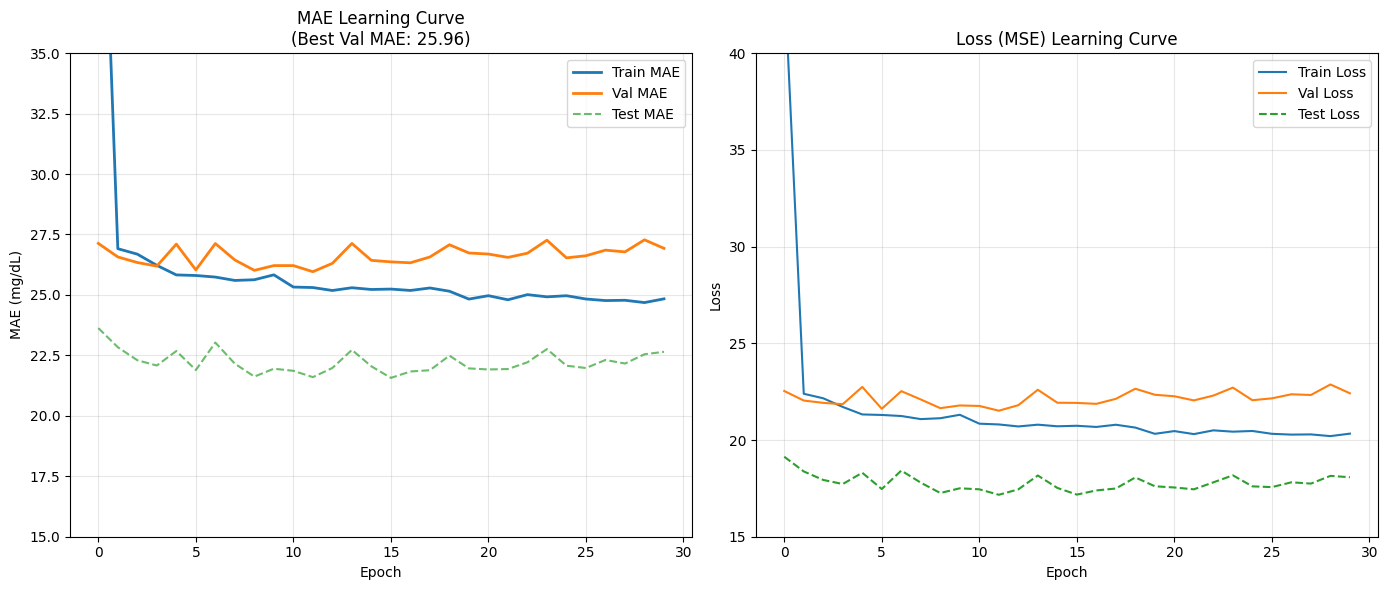

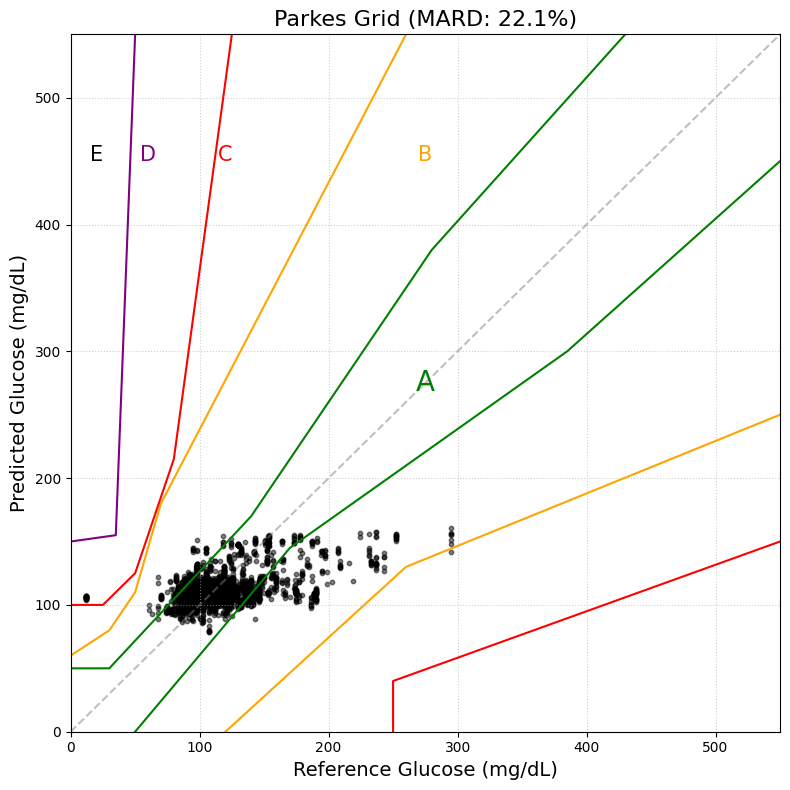

In [50]:
if __name__ == "__main__":
  main()